<div style="text-align:center;">

<h1 style="
background: linear-gradient(to right, #522f15, #7c2222);
color: #000;
color: rgb(255, 255, 255);
padding: 18px 35px;
border-radius: 15px;
font-family: serif;
letter-spacing: 1px;
box-shadow: 0px 4px 12px rgba(0,0,0,0.2);
display: inline-block;
margin: 15px auto;
">
<b>⚡ Electricity Demand Forecasting Using Machine Learning</b>
</h1>

</div>

<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Importing Libraries
</h3>


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge

from tabulate import tabulate

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings('ignore')


sns.set_style("whitegrid")
sns.set_context("talk")

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11


<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
LOADING AND UNDERSTANDING THE DATA
</h3>


In [2]:
df = pd.read_csv("power_supply.csv")

df.head()

,Year,Month,Energy Requirement,Energy Supplied,Energy not Supplied,Energy not Supplied %,Peak Demand,Peak Met,Demand not Met,Demand not Met %,Date
0,2020,1,105548,105158,390,0.4,171592,170976,616,0.4,2020-01-01
1,2020,2,104375,103815,560,0.5,179098,176388,2711,1.5,2020-02-01
2,2020,3,99382,98952,430,0.4,170749,170165,584,0.3,2020-03-01
3,2020,4,85030,84550,480,0.6,133200,132733,467,0.4,2020-04-01
4,2020,5,102651,102089,562,0.5,166890,166225,664,0.4,2020-05-01


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (76, 11)


In [4]:
print("Columns:", df.columns)

Columns: Index(['Year', 'Month', 'Energy Requirement', 'Energy Supplied',
       'Energy not Supplied', 'Energy not Supplied %', 'Peak Demand',
       'Peak Met', 'Demand not Met', 'Demand not Met %', 'Date'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   76 non-null     int64  
 1   Month                  76 non-null     int64  
 2   Energy Requirement     76 non-null     int64  
 3   Energy Supplied        76 non-null     int64  
 4   Energy not Supplied    76 non-null     int64  
 5   Energy not Supplied %  76 non-null     float64
 6   Peak Demand            76 non-null     int64  
 7   Peak Met               76 non-null     int64  
 8   Demand not Met         76 non-null     int64  
 9   Demand not Met %       76 non-null     float64
 10  Date                   76 non-null     object 
dtypes: float64(2), int64(8), object(1)
memory usage: 6.7+ KB


In [6]:
df.describe()

,Year,Month,Energy Requirement,Energy Supplied,Energy not Supplied,Energy not Supplied %,Peak Demand,Peak Met,Demand not Met,Demand not Met %
count,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000
mean,2022.684211,6.289474,127087.986842,126745.328947,342.342105,0.275000,205736.289474,204851.105263,886.855263,0.444737
std,1.849040,3.509286,16609.467845,16678.656048,368.650966,0.293542,27477.695136,27725.527950,1342.775958,0.659575
min,2020.000000,1.000000,85030.000000,84550.000000,19.000000,0.000000,129582.000000,129397.000000,0.000000,0.000000
25%,2021.000000,3.000000,112392.750000,112217.500000,113.750000,0.100000,185870.250000,185231.250000,124.500000,0.075000
50%,2023.000000,6.000000,128604.000000,128189.500000,276.000000,0.200000,209200.000000,208184.500000,482.000000,0.250000
75%,2024.000000,9.000000,140544.500000,140311.750000,470.250000,0.400000,224832.250000,224793.250000,1148.500000,0.600000
max,2026.000000,12.000000,155346.000000,155157.000000,2752.000000,2.000000,256117.000000,256117.000000,8657.000000,4.000000


<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Data Cleaning 
</h3>


In [7]:
df.duplicated().sum() 

np.int64(0)

In [8]:
df.isnull().sum()

Year                     0
Month                    0
Energy Requirement       0
Energy Supplied          0
Energy not Supplied      0
Energy not Supplied %    0
Peak Demand              0
Peak Met                 0
Demand not Met           0
Demand not Met %         0
Date                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Year                       int64
Month                      int64
Energy Requirement         int64
Energy Supplied            int64
Energy not Supplied        int64
Energy not Supplied %    float64
Peak Demand                int64
Peak Met                   int64
Demand not Met             int64
Demand not Met %         float64
Date                      object
dtype: object

In [11]:
df['Year'].unique()

array([2020, 2021, 2022, 2023, 2024, 2025, 2026])

In [12]:
numeric_cols = [
    'Energy Requirement',
    'Energy Supplied',
    'Energy not Supplied',
    'Energy not Supplied %',
    'Peak Demand',
    'Peak Met',
    'Demand not Met',
    'Demand not Met %',
    
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

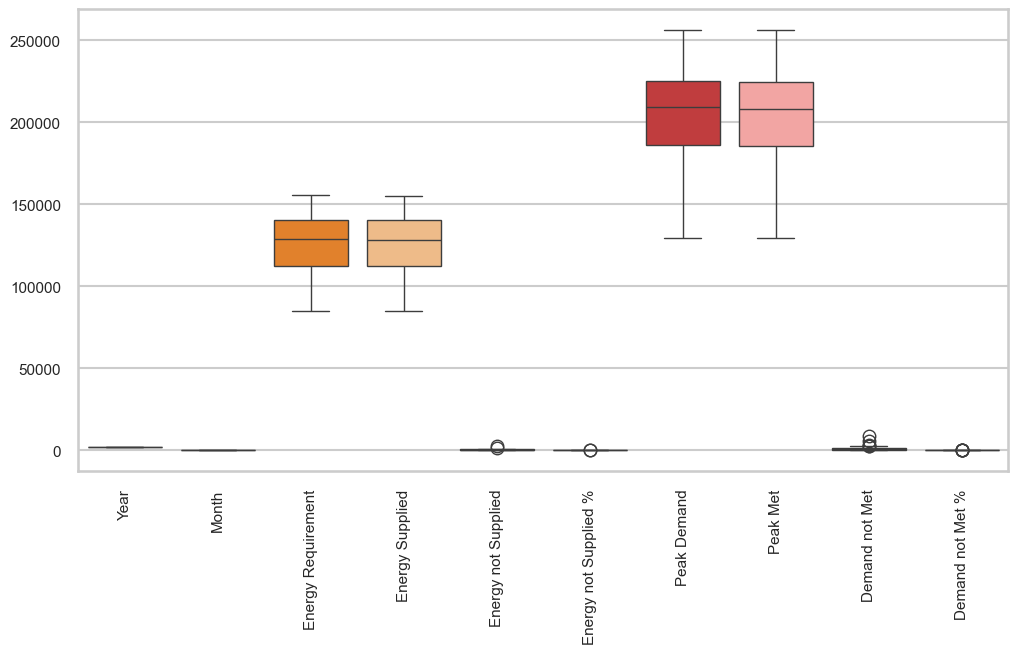

In [13]:
sns.boxplot(data=df, palette="tab20")
plt.xticks(rotation=90)
plt.show()

<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Exploratory Data Analysis
</h3>


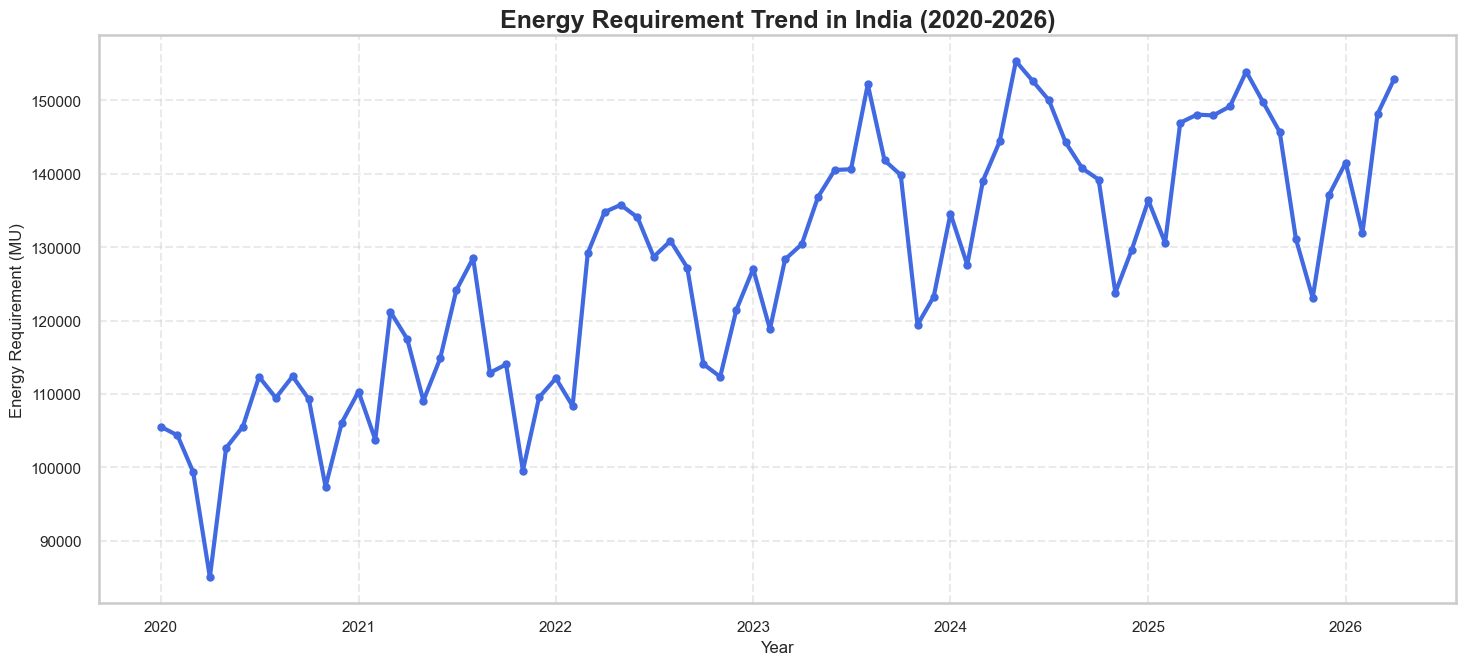

In [14]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

plt.figure(figsize=(15,7))

plt.plot(
    df['Date'],
    df['Energy Requirement'],
    marker='o',
    markersize=5,
    linewidth=3,
    color='royalblue'
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title(
    'Energy Requirement Trend in India (2020-2026)',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Energy Requirement (MU)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

The graph indicates a steady rise in India's energy requirement between 2020 and 2026. Although monthly demand fluctuates due to seasonal factors, the long-term trend demonstrates a significant increase in electricity consumption over the years.

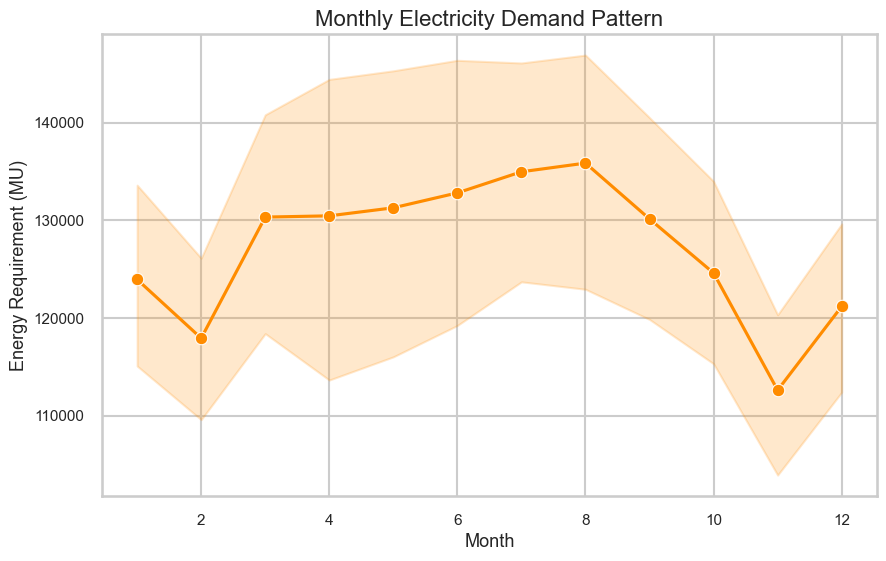

In [15]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x='Month',
    y='Energy Requirement',
    data=df,
    marker='o',
    color='darkorange'
)

plt.title('Monthly Electricity Demand Pattern')
plt.xlabel('Month')
plt.ylabel('Energy Requirement (MU)')

plt.show()

Electricity demand varies across months, indicating seasonal patterns. Higher demand months may be associated with increased cooling or industrial activity.

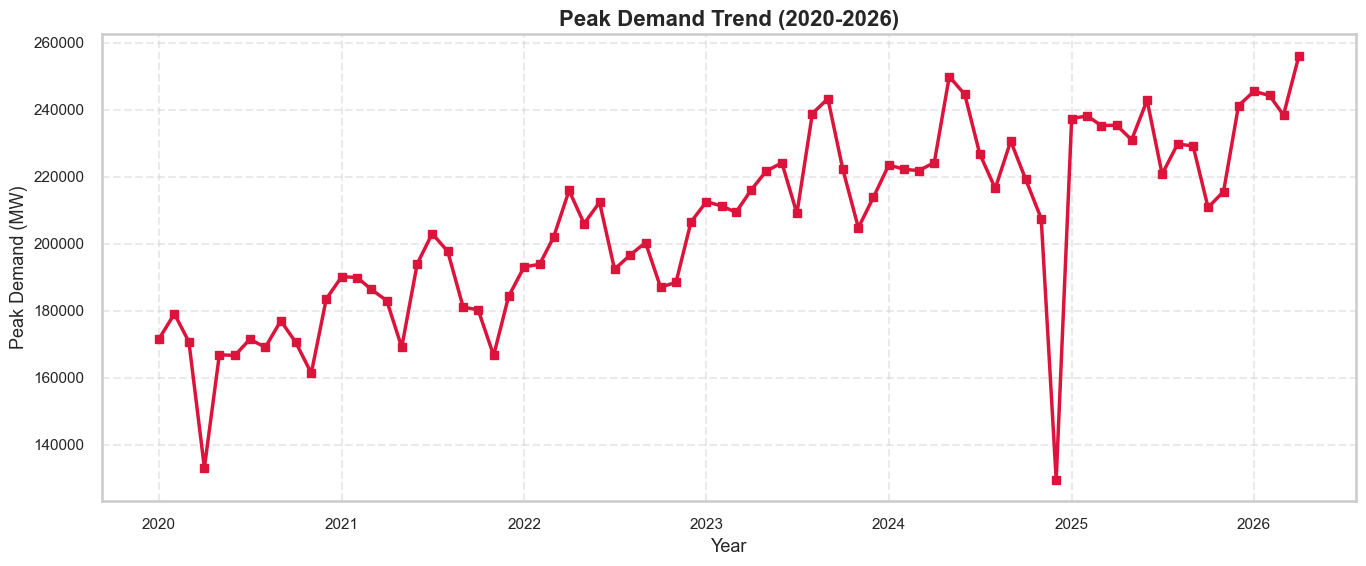

In [16]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Peak Demand'],
    marker='s',
    markersize=6,
    linewidth=2.5,
    color='crimson'
)

plt.title(
    'Peak Demand Trend (2020-2026)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Peak Demand (MW)')

ax = plt.gca()

# Show only years
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

The graph shows a steady increase in India's peak electricity demand from 2020 to 2026. Despite occasional fluctuations, the overall trend highlights rising power consumption and increasing stress on the electricity grid due to economic and population growth

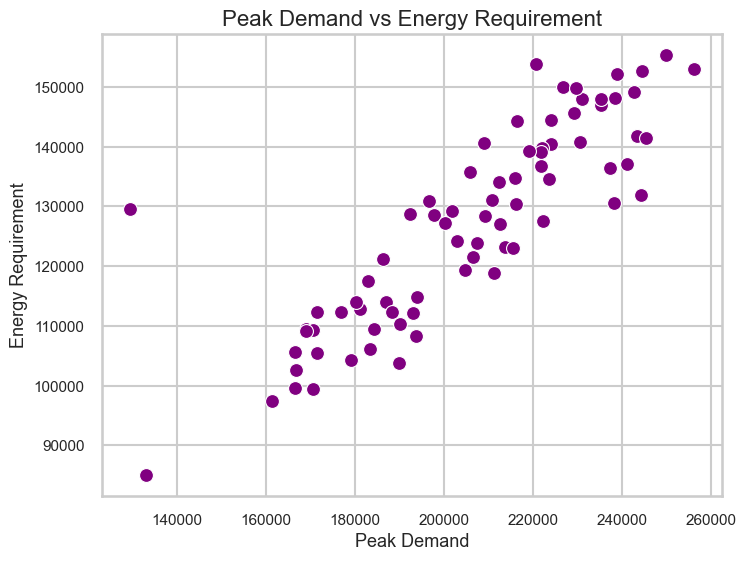

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Peak Demand',
    y='Energy Requirement',
    data=df,
    color='purple',
    s=100
)

plt.title('Peak Demand vs Energy Requirement')

plt.show()

A positive relationship is observed between Peak Demand and Energy Requirement. As peak demand increases, overall energy consumption also increases.

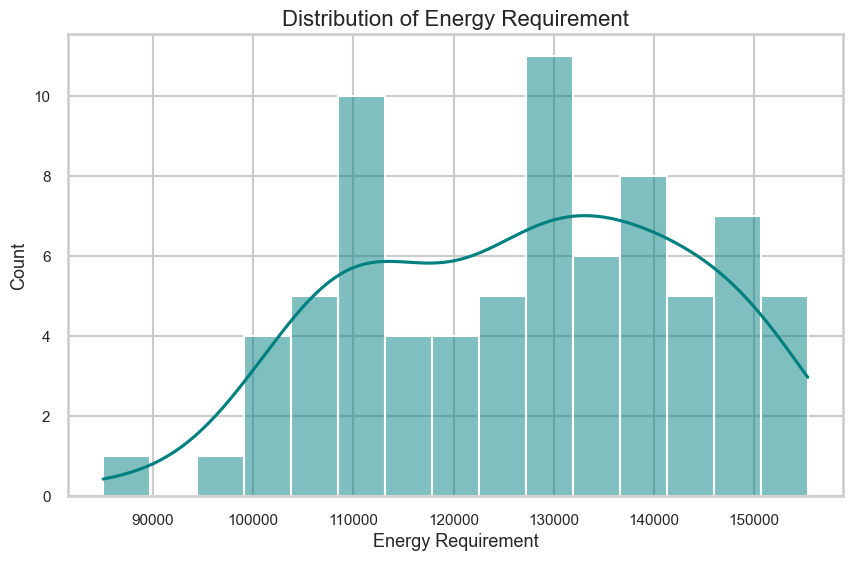

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Energy Requirement'],
    kde=True,
    color='teal',
    bins=15
)

plt.title('Distribution of Energy Requirement')
plt.xlabel('Energy Requirement')

plt.show()

Most monthly energy requirement values fall between 110,000 MU and 145,000 MU. The highest number of observations is around 130,000 MU, indicating that this is the most common demand level during the study period.

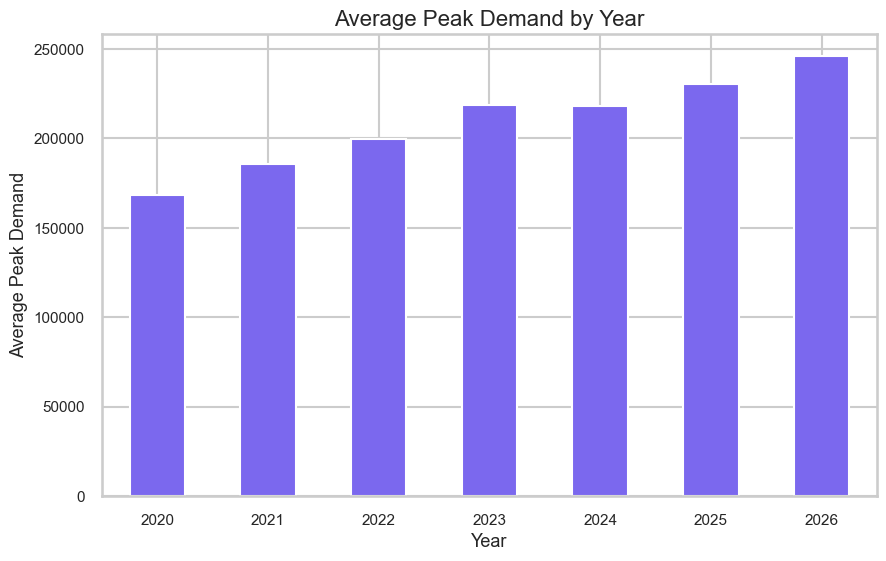

In [19]:
yearly = df.groupby('Year')['Peak Demand'].mean()

plt.figure(figsize=(10,6))

yearly.plot(
    kind='bar',
    color='mediumslateblue'
)

plt.title('Average Peak Demand by Year')
plt.xlabel('Year')
plt.ylabel('Average Peak Demand')

plt.xticks(rotation=0)

plt.show()

Average electricity demand has increased steadily from 2020 to 2026, indicating continuous growth in energy consumption and the need for efficient power planning.

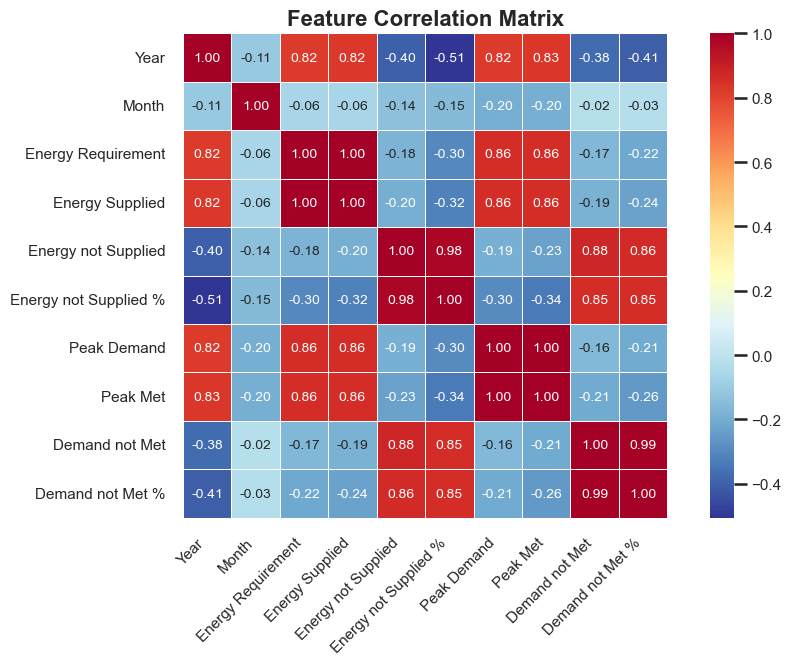

In [20]:
plt.figure(figsize=(10,7))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    linewidths=0.5,
    square=True,
    annot_kws={'size':10}
)

plt.title(
    'Feature Correlation Matrix',
    fontsize=16,
    fontweight='bold'
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The heatmap reveals that Peak Demand, Peak Met, and Energy Supplied are the most influential variables associated with Energy Requirement, making them valuable predictors for demand forecasting.

<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Feature Selection
</h3>


In [21]:
# Features
X = df[
    [
        "Year",
        "Month",
        "Peak Met",
        "Energy Requirement"
    ]
]

# Target
y = df['Peak Demand']

<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Train-Test Split 
</h3>


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (60, 4)
Testing data: (16, 4)


<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Scaling 
</h3>


In [23]:
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
Model Training 
</h3>


<h3 style="color:#ff6f00; font-weight:bold;">
Linear Regression 
</h3>

In [24]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

<h3 style="color:#ff6f00; font-weight:bold;">
Random Forest Regressor
</h3>

In [25]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

<h3 style="color:#ff6f00; font-weight:bold;">
Decision Tree
</h3>

In [26]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">
 Evaluation (MAE, RMSE, R²)
</h3>


In [27]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("-"*30)
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R²  :", r2_score(y_test, y_pred))

evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("Decision Tree", y_test, dt_pred)


Linear Regression
------------------------------
MAE : 599.9764641233814
RMSE: 686.8119914878231
R²  : 0.9991957767441936

Random Forest
------------------------------
MAE : 1645.2262499999997
RMSE: 2158.2418109597925
R²  : 0.9920585264712949

Decision Tree
------------------------------
MAE : 3942.4375
RMSE: 5310.777726708207
R²  : 0.9519141674820415


In [28]:
print(df[['Peak Demand', 'Energy Requirement']].corr())

                    Peak Demand  Energy Requirement
Peak Demand            1.000000            0.855832
Energy Requirement     0.855832            1.000000


<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">Comparison Table
</h3>


In [29]:
table =[["Model",'R2 Score'],
        ["Linear Regression", round(r2_score(y_test, lr_pred), 4)],
        ["Random Forest", round(r2_score(y_test, rf_pred), 4)],
        ["Decision Tree", round(r2_score(y_test, dt_pred), 4)]]
print(tabulate(table,headers='firstrow',tablefmt="github"))

| Model             |   R2 Score |
|-------------------|------------|
| Linear Regression |     0.9992 |
| Random Forest     |     0.9921 |
| Decision Tree     |     0.9519 |


<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">Hyperparameter tuning using GridSearchCV
</h3>


In [30]:
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['squared_error']
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)



Best Parameters: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV Score: 0.975115127545417


In [31]:
best_dt = grid.best_estimator_

y_pred_tuned = best_dt.predict(X_test)

In [32]:
print("R² :", r2_score(y_test, y_pred_tuned))
print("MAE:", mean_absolute_error(y_test, y_pred_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))

R² : 0.9855953448282988
MAE: 2100.508333333333
RMSE: 2906.7052068593603


<h3 style="color:#ff6f00; font-weight:bold;">
Prediction
</h3>

In [33]:
test_row = X.iloc[[0]]

print("Actual:", y.iloc[0])
print("Predicted:", best_dt.predict(test_row)[0])

Actual: 171592
Predicted: 170214.8


<h3 style="
background: linear-gradient(to right, #522f15, #7c2222);
text-align:left;
color:white;
font-family:serif;
border-radius: 12px;
letter-spacing:1px;
padding: 12px 20px;
display:inline-block;
">Feature Importance
</h3>


In [34]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
2            Peak Met    0.999054
1               Month    0.000798
0                Year    0.000147
3  Energy Requirement    0.000000


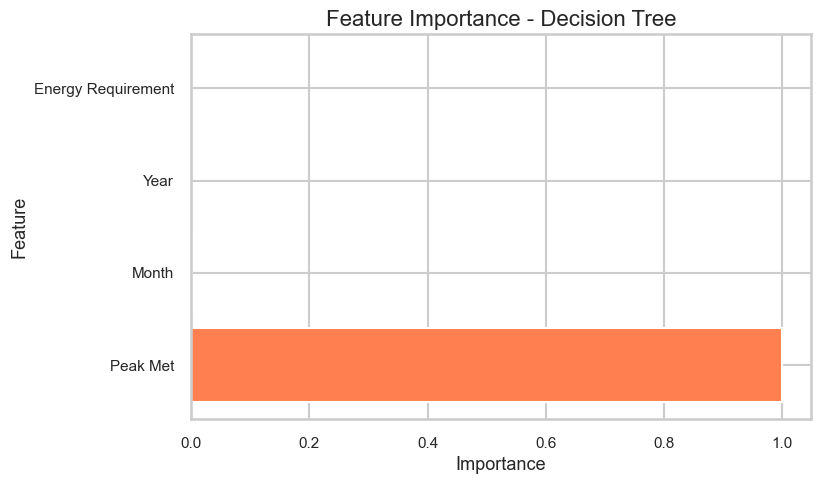

In [35]:
plt.figure(figsize=(8,5))
plt.barh(
    importance['Feature'],
    importance['Importance'],
    color='coral'
)

plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

<div style="
background: linear-gradient(135deg, #0f172a, #1e40af);
padding: 25px;
border-radius: 15px;
border-left: 8px solid #fbbf24;
box-shadow: 0px 4px 15px rgba(0,0,0,0.25);
color: white;
font-family: Arial, sans-serif;
line-height: 1.8;
">

<h2 style="color:#fbbf24; margin-top:0;">
 Project Conclusion
</h2>

<p style="font-size:16px; text-align:justify;">
This project focused on developing an <b>Electricity Demand Forecasting System</b> using machine learning techniques to predict future power demand based on historical electricity consumption data.
</p>

<p style="font-size:16px; text-align:justify;">
The dataset was carefully preprocessed and analyzed through <b>Exploratory Data Analysis (EDA)</b> to identify important trends, seasonal patterns, and relationships among key variables. Features <br>such as <b>Year, Month, Peak Met,</b> and <b>Energy Requirement</b> were utilized to predict <b>Peak Demand</b>, enabling the model to learn underlying demand patterns effectively.
</p>

<p style="font-size:16px; text-align:justify;">
Multiple machine learning algorithms were developed and evaluated to determine the most suitable forecasting approach. Among the tested models, the <span style="color:#fbbf24;"><b>Decision Tree Regressor</b></span> <br>demonstrated strong predictive capability and was selected as the final model due to its ability to capture complex patterns within the dataset while maintaining interpretability.
</p>

<p style="font-size:16px; text-align:justify;">
The results indicate that machine learning can provide reliable and accurate electricity demand forecasts, making it a valuable tool for modern power system management. Accurate forecasting <br>can support utilities in optimizing resource allocation, improving load balancing, reducing operational costs, and enhancing overall grid efficiency.
</p>

<p style="font-size:16px; text-align:justify;">
Future improvements may include the integration of additional influencing factors such as <b>weather conditions, economic indicators, population growth, and renewable energy generation data</b>.<br> These enhancements could further improve prediction accuracy and contribute to the development of intelligent, data-driven energy management systems.
</p>

<div style="
background:#fbbf24;
color:#000;
padding:12px;
border-radius:8px;
margin-top:15px;
font-weight:bold;
text-align:center;
font-size:17px;">
⚡ Final Selected Model: Decision Tree Regressor
</div>

</div>

In [36]:
joblib.dump(best_dt, 'decision_tree_model.pkl')

print("Model saved successfully!")

Model saved successfully!
